In [1]:
# ==========================================
# SALES DATA ANALYSIS PROJECT IN PYTHON
# ==========================================

# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
# ------------------------------------------
# LOAD DATA
# ------------------------------------------

# Replace with your actual file path
df = pd.read_excel(r'D:\sales_data.xlsx')

# Display first 5 rows
print(df.head())

# Check dataset information
print(df.info())

     Order_ID Customer_ID Order_Date  Ship_Date   Region  Country  \
0  ORD-100001   CUST-5012 2025-10-16 2025-10-17    South   Canada   
1  ORD-100002   CUST-4811 2025-03-08 2025-03-09  Central      UAE   
2  ORD-100003   CUST-1106 2025-03-05 2025-03-07    South  Germany   
3  ORD-100004   CUST-6881 2024-12-10 2024-12-11     East      UAE   
4  ORD-100005   CUST-6925 2024-05-07 2024-05-11  Central   Canada   

  Sales_Channel Customer_Segment     Category  Subcategory  ...  \
0     Wholesale         Consumer  Electronics  Accessories  ...   
1        Online   Small Business  Electronics      Laptops  ...   
2        Retail        Corporate      Fashion         Kids  ...   
3        Retail         Consumer  Electronics       Phones  ...   
4     Wholesale         Consumer  Electronics  Accessories  ...   

   Discount_Rate  Discount_Amount  Net_Sales     Cost   Profit  \
0           0.10           199.22    1792.93  1095.01   697.92   
1           0.05           271.17    5152.17  2646

In [3]:
# ==========================================
# QUESTION 1
# What is the total revenue, total profit,
# and average order value?
# ==========================================

total_revenue = df['Net_Sales'].sum()
total_profit = df['Profit'].sum()
average_order_value = df['Net_Sales'].mean()

print("\n===== BUSINESS OVERVIEW =====")
print("Total Revenue:", round(total_revenue, 2))
print("Total Profit:", round(total_profit, 2))
print("Average Order Value:", round(average_order_value, 2))




===== BUSINESS OVERVIEW =====
Total Revenue: 68308513.23
Total Profit: 25689059.67
Average Order Value: 4553.9



===== CATEGORY ANALYSIS =====
                   Net_Sales      Profit
Category                                
Furniture        14228361.88  5383099.10
Health           13958190.58  5295523.46
Electronics      13673371.11  5120459.04
Fashion          13343271.46  4993627.25
Office Supplies  13105318.20  4896350.82


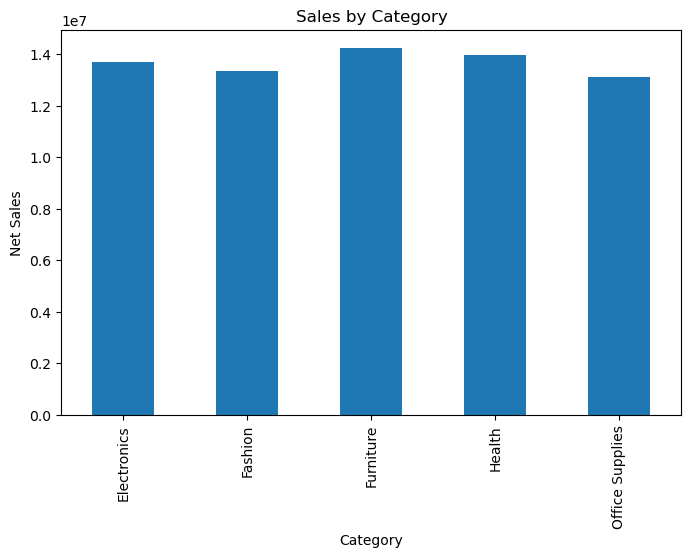

In [4]:
# ==========================================
# QUESTION 2
# Which product categories generate the
# highest sales and profits?
# ==========================================

category_analysis = df.groupby('Category')[['Net_Sales', 'Profit']].sum()

print("\n===== CATEGORY ANALYSIS =====")
print(category_analysis.sort_values(by='Net_Sales', ascending=False))

# Plot Category Sales
category_analysis['Net_Sales'].plot(kind='bar', figsize=(8,5))
plt.title('Sales by Category')
plt.ylabel('Net Sales')
plt.show()




===== REGION SALES =====
Region
West       14023232.46
North      13779051.14
South      13751134.09
East       13677779.61
Central    13077315.93
Name: Net_Sales, dtype: float64

===== COUNTRY SALES =====
Country
Germany    14145285.27
UK         13698450.49
USA        13671385.47
Canada     13590774.34
UAE        13202617.66
Name: Net_Sales, dtype: float64


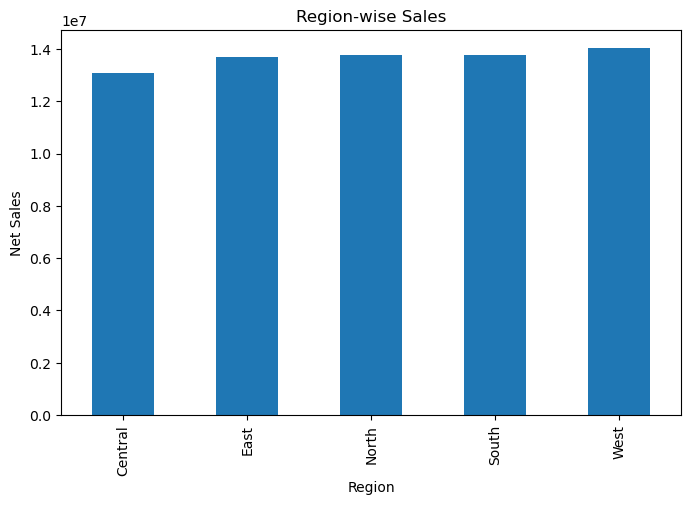

In [5]:
# ==========================================
# QUESTION 3
# Which region and country have the best
# sales performance?
# ==========================================

region_sales = df.groupby('Region')['Net_Sales'].sum()
country_sales = df.groupby('Country')['Net_Sales'].sum()

print("\n===== REGION SALES =====")
print(region_sales.sort_values(ascending=False))

print("\n===== COUNTRY SALES =====")
print(country_sales.sort_values(ascending=False))

# Plot Region Sales
region_sales.plot(kind='bar', figsize=(8,5))
plt.title('Region-wise Sales')
plt.ylabel('Net Sales')
plt.show()


===== MONTHLY TREND =====
          Net_Sales      Profit
Month                          
2024-01  2858034.44  1084092.97
2024-02  2707452.98   995605.15
2024-03  3094700.68  1165946.09
2024-04  3052237.23  1131918.52
2024-05  2773979.34  1051118.85
2024-06  2908408.49  1115678.05
2024-07  2662443.14  1005500.29
2024-08  2988573.25  1126810.41
2024-09  2677028.38  1011780.87
2024-10  2807789.28  1068379.86
2024-11  2828682.54  1072793.84
2024-12  2984951.85  1114131.16
2025-01  2868908.60  1065085.20
2025-02  2537504.64   965998.36
2025-03  3068062.67  1139993.54
2025-04  2683974.11  1026782.66
2025-05  2837615.45  1066716.14
2025-06  2702130.80  1001179.47
2025-07  3124685.94  1169329.83
2025-08  2836588.80  1058529.35
2025-09  2698495.24   999403.57
2025-10  2954915.29  1132183.75
2025-11  2850237.32  1064236.44
2025-12  2801112.77  1055865.30


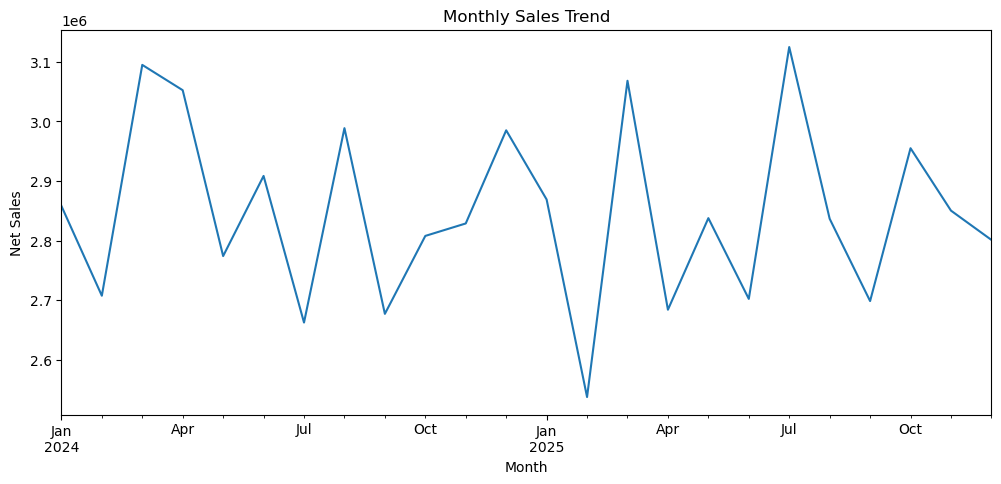

In [6]:
# ==========================================
# QUESTION 4
# How do monthly sales and profits change
# over time?
# ==========================================

# Convert Order_Date to datetime
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

# Create Month-Year column
df['Month'] = df['Order_Date'].dt.to_period('M')

monthly_trend = df.groupby('Month')[['Net_Sales', 'Profit']].sum()

print("\n===== MONTHLY TREND =====")
print(monthly_trend)

# Plot Monthly Sales Trend
monthly_trend['Net_Sales'].plot(figsize=(12,5))
plt.title('Monthly Sales Trend')
plt.ylabel('Net Sales')
plt.xlabel('Month')
plt.show()



===== A/B TEST RESULTS =====
Marketing_Campaign
Variant_B    26.374069
Variant_A    23.865917
Control      18.709167
Name: Website_Converted, dtype: float64


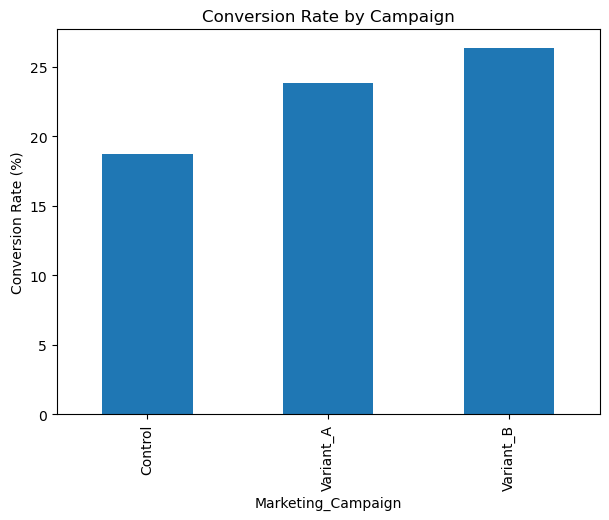

In [7]:
# ==========================================
# QUESTION 5
# Which marketing campaign has the highest
# website conversion rate?
# ==========================================

ab_test = df.groupby('Marketing_Campaign')['Website_Converted'].mean() * 100

print("\n===== A/B TEST RESULTS =====")
print(ab_test.sort_values(ascending=False))

# Plot Conversion Rates
ab_test.plot(kind='bar', figsize=(7,5))
plt.title('Conversion Rate by Campaign')
plt.ylabel('Conversion Rate (%)')
plt.show()



===== TOP PROFITABLE PRODUCTS =====
Subcategory
Chairs           1845919.67
Desks            1775448.05
Personal Care    1774847.31
Laptops          1774495.57
Supplements      1771787.08
Storage          1761731.38
Fitness          1748889.07
Binders          1703559.64
Women            1701469.83
Accessories      1700169.35
Name: Profit, dtype: float64


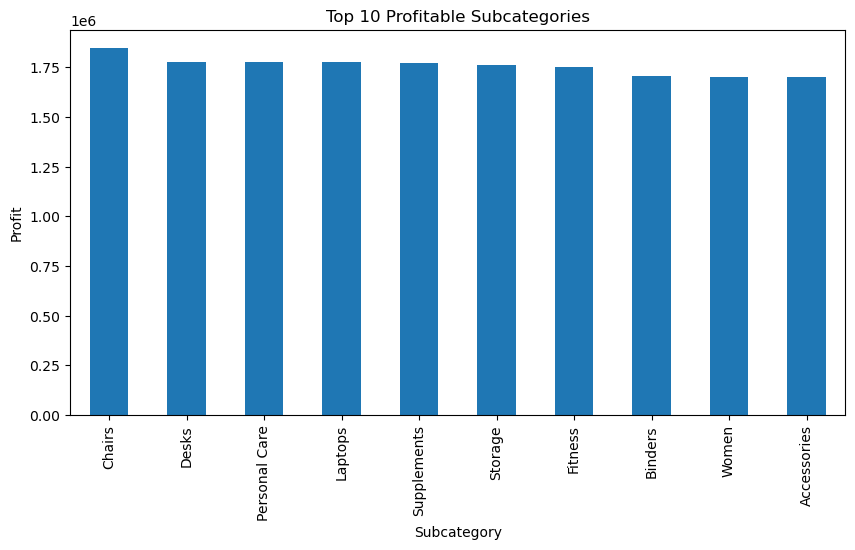

In [8]:
# Top 10 Most Profitable Products
# ==========================================

top_products = df.groupby('Subcategory')['Profit'].sum().sort_values(ascending=False)

print("\n===== TOP PROFITABLE PRODUCTS =====")
print(top_products.head(10))

top_products.head(10).plot(kind='bar', figsize=(10,5))
plt.title('Top 10 Profitable Subcategories')
plt.ylabel('Profit')
plt.show()


1. CUSTOMER SEGMENT ANALYSIS
                    Net_Sales      Profit  Total_Orders
Customer_Segment                                       
Consumer          23157445.95  8707326.18          5009
Corporate         22708077.82  8518491.83          5010
Small Business    22442989.46  8463241.66          4981


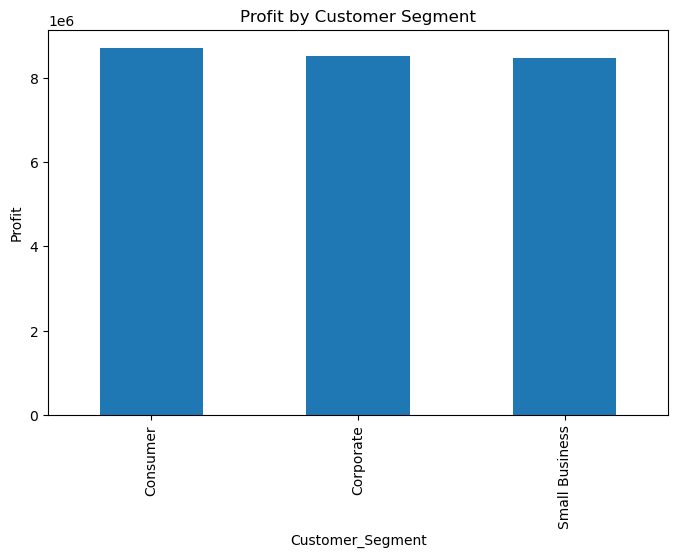

In [9]:
# Which customer segment is the most valuable
# based on sales, profit, and order frequency?
# =========================================================

customer_segment_analysis = df.groupby('Customer_Segment').agg({
    'Net_Sales': 'sum',
    'Profit': 'sum',
    'Order_ID': 'count'
}).rename(columns={'Order_ID': 'Total_Orders'})

print("\n==============================")
print("1. CUSTOMER SEGMENT ANALYSIS")
print("==============================")
print(customer_segment_analysis)

# Visualization
customer_segment_analysis['Profit'].plot(kind='bar', figsize=(8,5))
plt.title('Profit by Customer Segment')
plt.ylabel('Profit')
plt.show()



2. HIGH SALES BUT LOW MARGIN PRODUCTS
                Net_Sales      Profit  Profit_Margin
Subcategory                                         
Chairs         4860141.35  1845919.67      37.980782
Laptops        4771694.85  1774495.57      37.187952
Desks          4758697.68  1775448.05      37.309537
Fitness        4699333.25  1748889.07      37.215685
Personal Care  4633425.19  1774847.31      38.305298
Supplements    4625432.14  1771787.08      38.305331
Storage        4609522.85  1761731.38      38.219387
Accessories    4536195.74  1700169.35      37.480070
Binders        4530673.70  1703559.64      37.600581
Women          4492661.42  1701469.83      37.872202


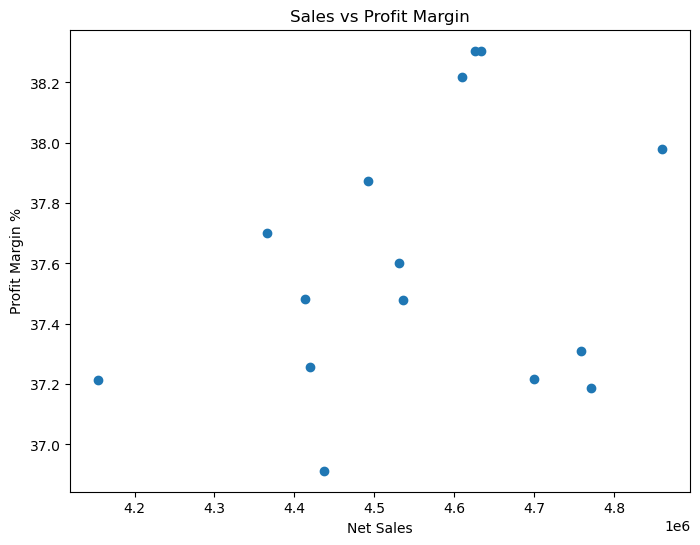

In [10]:
# Which products have high sales but low profit margins?
# =========================================================

product_analysis = df.groupby('Subcategory').agg({
    'Net_Sales': 'sum',
    'Profit': 'sum'
})

product_analysis['Profit_Margin'] = (
    product_analysis['Profit'] / product_analysis['Net_Sales']
) * 100

# High sales but low margin
risk_products = product_analysis.sort_values(
    by=['Net_Sales', 'Profit_Margin'],
    ascending=[False, True]
)

print("\n==============================")
print("2. HIGH SALES BUT LOW MARGIN PRODUCTS")
print("==============================")
print(risk_products.head(10))

# Scatter Plot
plt.figure(figsize=(8,6))
plt.scatter(product_analysis['Net_Sales'],
            product_analysis['Profit_Margin'])

plt.xlabel('Net Sales')
plt.ylabel('Profit Margin %')
plt.title('Sales vs Profit Margin')
plt.show()

In [12]:
import pandas as pd
from scipy.stats import chi2_contingency  # <-- add this

ab_table = pd.crosstab(
    df['Marketing_Campaign'],
    df['Website_Converted']
)

chi2, p, dof, expected = chi2_contingency(ab_table)

print("\n==============================")
print("3. A/B TESTING ANALYSIS")
print("==============================")

print("\nContingency Table:")
print(ab_table)

print("\nChi-Square Statistic:", round(chi2, 4))
print("P-value:", round(p, 6))

if p < 0.05:
    print("Result: Significant difference exists between campaigns.")
else:
    print("Result: No significant difference between campaigns.")


3. A/B TESTING ANALYSIS

Contingency Table:
Website_Converted      0     1
Marketing_Campaign            
Control             4106   945
Variant_A           3793  1189
Variant_B           3657  1310

Chi-Square Statistic: 86.6404
P-value: 0.0
Result: Significant difference exists between campaigns.



4. SALES FORECASTING MODEL
Mean Absolute Error: 137277.24
R2 Score: -0.3637


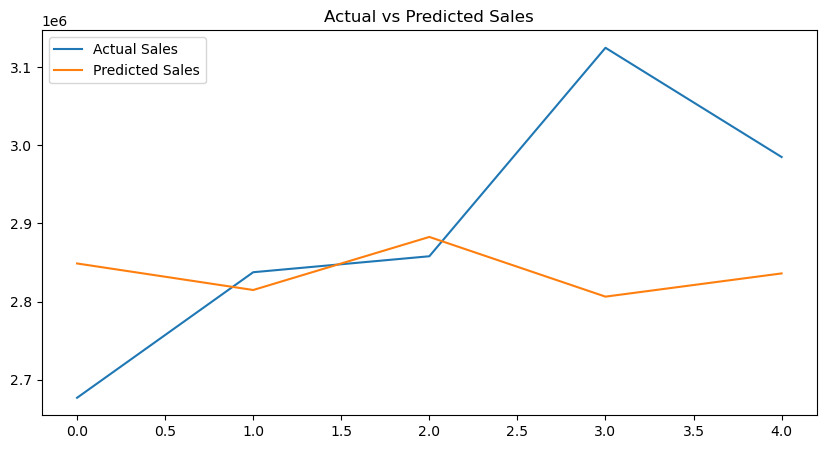

In [14]:
# Predict future sales using Linear Regression
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Ensure datetime format
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

# Monthly sales aggregation
monthly_sales = df.groupby(df['Order_Date'].dt.to_period('M'))['Net_Sales'].sum()

monthly_sales = monthly_sales.reset_index()
monthly_sales['Order_Date'] = monthly_sales['Order_Date'].astype(str)

# Create time index
monthly_sales['Month_Number'] = np.arange(len(monthly_sales))

X = monthly_sales[['Month_Number']]
y = monthly_sales['Net_Sales']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
predictions = model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("\n==============================")
print("4. SALES FORECASTING MODEL")
print("==============================")

print("Mean Absolute Error:", round(mae, 2))
print("R2 Score:", round(r2, 4))

# Plot
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label='Actual Sales')
plt.plot(predictions, label='Predicted Sales')
plt.legend()
plt.title('Actual vs Predicted Sales')
plt.show()


5. CUSTOMER SEGMENTATION
             Net_Sales    Profit  Frequency  Cluster
Customer_ID                                         
CUST-1001     10852.12   2876.63          4        1
CUST-1006       717.65    371.06          1        0
CUST-1007     29809.42  13148.39          4        2
CUST-1008      5254.67   2543.03          1        0
CUST-1010      3336.87   1514.98          1        0


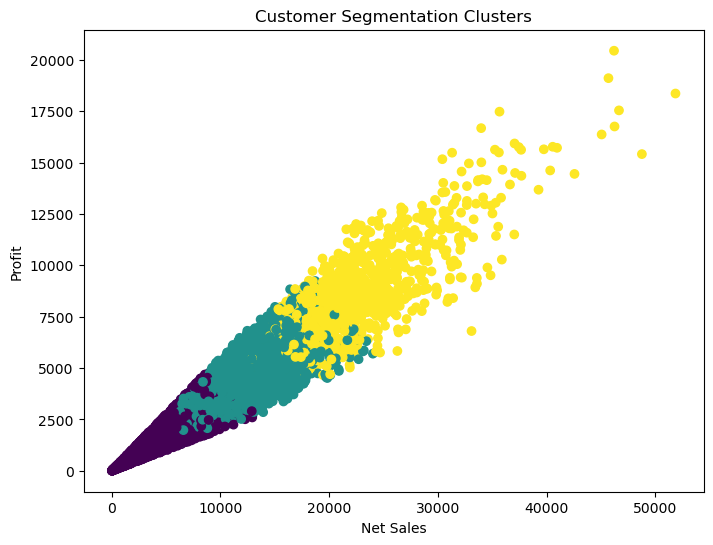

In [16]:
# Customer Segmentation using K-Means Clustering
# =========================================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Aggregate customer-level data
customer_data = df.groupby('Customer_ID').agg({
    'Net_Sales': 'sum',
    'Profit': 'sum',
    'Order_ID': 'count'
}).rename(columns={'Order_ID': 'Frequency'})

# Standardize data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(customer_data)

# KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
customer_data['Cluster'] = kmeans.fit_predict(scaled_data)

print("\n==============================")
print("5. CUSTOMER SEGMENTATION")
print("==============================")

print(customer_data.head())

# Cluster Visualization
plt.figure(figsize=(8,6))

plt.scatter(
    customer_data['Net_Sales'],
    customer_data['Profit'],
    c=customer_data['Cluster']
)

plt.xlabel('Net Sales')
plt.ylabel('Profit')
plt.title('Customer Segmentation Clusters')
plt.show()